In [23]:
from deep_neurographs import geometry
from deep_neurographs.utils import util
from deep_neurographs.utils.graph_util import GraphLoader

import networkx as nx
import numpy as np

In [19]:
def compute_path_lengths(graph):
    path_lengths = list()
    for nodes in nx.connected_components(graph):
        root = util.sample_once(nodes)
        path_lengths.append(graph.component_path_length(root))
    return path_lengths


In [15]:
# Initializations
graph_loader = GraphLoader(min_size=0, progress_bar=True)

# Load uncorrected
pointer = "/root/capsule/data/processed-swcs.zip"
fragments_graph = graph_loader.run(pointer)

# Load corrected
pointer = "/root/capsule/data/corrected-processed-swcs.zip"
corrected_fragments_graph = graph_loader.run(pointer)

Extract Graphs: 100%|██████████| 326362/326362 [02:31<00:00, 2149.88it/s]


In [20]:
path_lengths = compute_path_lengths(fragments_graph)

In [21]:
corrected_path_lengths = compute_path_lengths(corrected_fragments_graph)

In [84]:
print("Median Path Length of Fragments:", np.mean([p for p in path_lengths if p > 100]))
print("Median Path Length of Corrected Fragments:", np.mean([p for p in corrected_path_lengths if p > 100]))

print("Median Path Length of Fragments:", np.std([p for p in path_lengths if p > 100]))
print("Median Path Length of Corrected Fragments:", np.std([p for p in corrected_path_lengths if p > 100]))

Median Path Length of Fragments: 404.98417183115595
Median Path Length of Corrected Fragments: 492.4962635908018
Median Path Length of Fragments: 963.226709486063
Median Path Length of Corrected Fragments: 1332.4386342216383


In [32]:

root = util.sample_once(fragments_graph.nodes)
print(fragments_graph.component_path_length(root))

27.577853202819824


In [89]:
def spaced_idxs(arr_length, k):
    """
    Generates an array of indices based on a specified step size and ensures
    the last index is included.

    Parameters:
    ----------
    arr_length : int
        Length of array to be sampled from.
    k : int
        Step size for generating indices.

    Returns:
    -------
    numpy.ndarray
        Array of indices starting from 0 up to (but not including) the length
        of "container" spaced by "k". The last index before the length of
        "container" is guaranteed to be included in the output.

    """
    idxs = np.arange(0, arr_length + k, k)[:-1]
    if arr_length % 1 == 0:
        idxs = np.append(idxs, arr_length - 1)
    return idxs

arr = np.arange(5, 27)
n_idxs = len(arr)
idxs = spaced_idxs(n_idxs, 2)

print("idxs:", idxs)
print("arr:", arr)
print("sampled arr:", arr[idxs])

idxs: [ 0  2  4  6  8 10 12 14 16 18 20 21]
arr: [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
sampled arr: [ 5  7  9 11 13 15 17 19 21 23 25 26]


In [35]:
print(list(fragments_graph.neighbors(243367)))

[243366]


In [37]:
i = 243367
j = 243366
print(fragments_graph.edges[i, j])

{'length': 27.577853202819824, 'radius': array([2., 2., 2.], dtype=float16), 'xyz': array([[25122.207, 16795.387,  9192.288],
       [25113.566, 16794.256,  9181.711],
       [25104.64 , 16793.11 ,  9171.152]], dtype=float32), 'swc_id': '1674466736'}


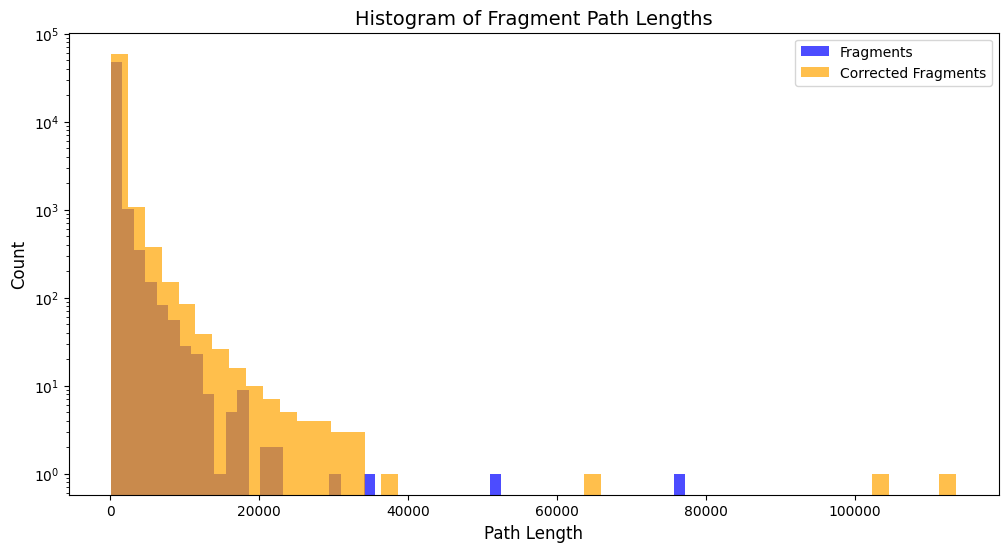

In [88]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Create the figure and axes
plt.figure(figsize=(12, 6))

# Plot the first histogram
plt.hist([p for p in path_lengths if p > 100], bins=50, alpha=0.7,  label='Fragments', color='blue')

# Plot the second histogram
plt.hist([p for p in corrected_path_lengths if p > 100], bins=50, alpha=0.7, label='Corrected Fragments', color='orange')

# Add labels, legend, and title
plt.xlabel('Path Length', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of Fragment Path Lengths', fontsize=14)
plt.legend(loc='upper right')

plt.yscale('log')


# Show the plot
#plt.tight_layout()
plt.show()

In [59]:
len(corrected_path_lengths)

235589